Traffic Log CSV

In [1]:
import pandas as pd

df = pd.read_csv("/home/huimin/testing/p4/ddos/dataset/traffic_log.csv")
df.head()



,timestamp,interface,host_name,src_ip,packet_rate,byte_rate,avg_packet_size,tcp_count,udp_count,icmp_count,syn_count,tcp_ratio,udp_ratio,icmp_ratio,severity,attack_type,action,is_blocked,label
0,2026-04-27 04:48:13,s1-eth1,host1,10.0.0.1,0,0,0.0,0,0,0,0,0.0,0.0,0.0,normal,normal,allow,0,normal
1,2026-04-27 04:48:13,s1-eth2,host2,10.0.0.2,0,0,0.0,0,0,0,0,0.0,0.0,0.0,normal,normal,allow,0,normal
2,2026-04-27 04:48:13,s1-eth3,host3,10.0.0.3,0,0,0.0,0,0,0,0,0.0,0.0,0.0,normal,normal,allow,0,normal
3,2026-04-27 04:48:14,s1-eth4,host4,10.0.0.100,0,0,0.0,0,0,0,0,0.0,0.0,0.0,normal,normal,allow,0,normal
4,2026-04-27 04:48:15,s1-eth1,host1,10.0.0.1,0,0,0.0,0,0,0,0,0.0,0.0,0.0,normal,normal,allow,0,normal


In [2]:
df["attack_type"].value_counts()

attack_type
normal              496
tcp_syn_flood       184
mixed_or_unknown    174
udp_flood             6
Name: count, dtype: int64

In [3]:
features = [
    "packet_rate",
    "byte_rate",
    "avg_packet_size"
]

In [4]:
X = df[features]
y = df["attack_type"]   # better than just normal/attack

In [5]:
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [6]:
df["attack_type"].value_counts()

attack_type
normal              496
tcp_syn_flood       184
mixed_or_unknown    174
udp_flood             6
Name: count, dtype: int64

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

In [8]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

                  precision    recall  f1-score   support

mixed_or_unknown       1.00      0.95      0.98        43
          normal       1.00      1.00      1.00        86
   tcp_syn_flood       0.96      1.00      0.98        43

        accuracy                           0.99       172
       macro avg       0.99      0.98      0.98       172
    weighted avg       0.99      0.99      0.99       172



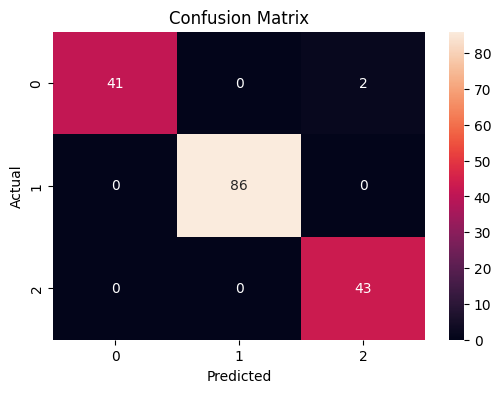

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

CIC_DDOS2019 - UDP 

In [1]:
import pandas as pd

df_udp = pd.read_parquet("/home/huimin/testing/p4/ddos/dataset//3/UDP-training.parquet")

df_udp.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,216631,6,0,2088.0,0.0,393.0,321.0,348.0,35.088459,...,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UDP
1,17,2,2,0,802.0,0.0,401.0,401.0,401.0,0.000000,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UDP
2,17,48,2,0,766.0,0.0,383.0,383.0,383.0,0.000000,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UDP
3,17,107319,4,0,1398.0,0.0,369.0,330.0,349.5,22.516661,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UDP
4,17,107271,4,0,1438.0,0.0,389.0,330.0,359.5,34.063667,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UDP


In [2]:
import pandas as pd

df_udp = pd.read_parquet("/home/huimin/testing/p4/ddos/dataset/3/UDP-training.parquet")

# Check memory usage and data types
print(df_udp.info(memory_usage='deep'))

# Look at the specific attack labels
if 'Label' in df_udp.columns:
    print(df_udp['Label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17770 entries, 0 to 17769
Data columns (total 78 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Protocol                  17770 non-null  int8    
 1   Flow Duration             17770 non-null  int32   
 2   Total Fwd Packets         17770 non-null  int16   
 3   Total Backward Packets    17770 non-null  int16   
 4   Fwd Packets Length Total  17770 non-null  float32 
 5   Bwd Packets Length Total  17770 non-null  float32 
 6   Fwd Packet Length Max     17770 non-null  float32 
 7   Fwd Packet Length Min     17770 non-null  float32 
 8   Fwd Packet Length Mean    17770 non-null  float32 
 9   Fwd Packet Length Std     17770 non-null  float32 
 10  Bwd Packet Length Max     17770 non-null  float32 
 11  Bwd Packet Length Min     17770 non-null  float32 
 12  Bwd Packet Length Mean    17770 non-null  float32 
 13  Bwd Packet Length Std     17770 non-null  floa

In [4]:
import pandas as pd
import numpy as np

# 1. Clean column names (removes leading/trailing spaces like " Label" -> "Label")
df_udp.columns = df_udp.columns.str.strip()

# 2. Filter first to save memory
df_udp2 = df_udp[df_udp["Label"].isin(["Benign", "UDP"])].copy()

# 3. Create aligned dataset
udp_clean = pd.DataFrame()

# Feature mapping (using .get() or checking names to be safe)
udp_clean["packet_rate"] = df_udp2["Flow Packets/s"]
udp_clean["byte_rate"] = df_udp2["Flow Bytes/s"]
udp_clean["avg_packet_size"] = df_udp2["Avg Packet Size"]

udp_clean["tcp_count"] = 0
udp_clean["udp_count"] = (df_udp2["Protocol"] == 17).astype(int)
udp_clean["icmp_count"] = 0
udp_clean["syn_count"] = df_udp2["SYN Flag Count"]

udp_clean["tcp_ratio"] = (df_udp2["Protocol"] == 6).astype(int)
udp_clean["udp_ratio"] = (df_udp2["Protocol"] == 17).astype(int)
udp_clean["icmp_ratio"] = (df_udp2["Protocol"] == 1).astype(int)

# --- FIX FOR WARNING ---
# Convert to string first, then replace. This avoids the CategoricalDtype warning.
udp_clean["attack_type"] = df_udp2["Label"].astype(str).replace({
    "Benign": "normal",
    "UDP": "udp_flood"
})

# 4. Clean invalid values (inf and nan)
udp_clean = udp_clean.replace([np.inf, -np.inf], np.nan)
udp_clean = udp_clean.dropna()

# 5. Outlier removal for realistic network simulation
udp_clean = udp_clean[udp_clean["packet_rate"] < 1_000_000]

print(f"Final dataset shape: {udp_clean.shape}")
udp_clean.head()

Final dataset shape: (16919, 11)


,packet_rate,byte_rate,avg_packet_size,tcp_count,udp_count,icmp_count,syn_count,tcp_ratio,udp_ratio,icmp_ratio,attack_type
0,27.696867,9.638510e+03,401.5,0,1,0,0,0,1,0,udp_flood
2,41666.666667,1.595833e+07,574.5,0,1,0,0,0,1,0,udp_flood
3,37.272058,1.302658e+04,432.0,0,1,0,0,0,1,0,udp_flood
4,37.288736,1.340530e+04,442.0,0,1,0,0,0,1,0,udp_flood
5,41666.666667,1.670833e+07,601.5,0,1,0,0,0,1,0,udp_flood


In [5]:
udp_clean["attack_type"].value_counts()

attack_type
udp_flood    14335
normal        2584
Name: count, dtype: int64

In [6]:
normal_part = udp_clean[udp_clean["attack_type"] == "normal"]
udp_part = udp_clean[udp_clean["attack_type"] == "udp_flood"]

n = min(len(normal_part), len(udp_part))

udp_balanced = pd.concat([
    normal_part.sample(n=n, random_state=42),
    udp_part.sample(n=n, random_state=42)
]).sample(frac=1, random_state=42)

udp_balanced["attack_type"].value_counts()

attack_type
normal       2584
udp_flood    2584
Name: count, dtype: int64

In [8]:
udp_balanced.to_csv("/home/huimin/testing/p4/ddos/dataset/public_udp_clean.csv", index=False)

CIC_DDOS2019 - TCP

In [13]:
import pandas as pd
import numpy as np

syn_path = "/home/huimin/testing/p4/ddos/dataset/3/Syn-training.parquet"
df_syn = pd.read_parquet(syn_path)

# Check memory usage and data types
print(df_syn.info(memory_usage='deep'))

# Look at the specific attack labels
if 'Label' in df_syn.columns:
    print(df_syn['Label'].value_counts())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70336 entries, 0 to 70335
Data columns (total 78 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Protocol                  70336 non-null  int8    
 1   Flow Duration             70336 non-null  int32   
 2   Total Fwd Packets         70336 non-null  int16   
 3   Total Backward Packets    70336 non-null  int16   
 4   Fwd Packets Length Total  70336 non-null  float32 
 5   Bwd Packets Length Total  70336 non-null  float32 
 6   Fwd Packet Length Max     70336 non-null  float32 
 7   Fwd Packet Length Min     70336 non-null  float32 
 8   Fwd Packet Length Mean    70336 non-null  float32 
 9   Fwd Packet Length Std     70336 non-null  float32 
 10  Bwd Packet Length Max     70336 non-null  float32 
 11  Bwd Packet Length Min     70336 non-null  float32 
 12  Bwd Packet Length Mean    70336 non-null  float32 
 13  Bwd Packet Length Std     70336 non-null  floa

In [14]:
# Ensure columns are clean
df_syn.columns = df_syn.columns.str.strip()

# Keep only Benign and Syn
df_syn2 = df_syn[df_syn["Label"].isin(["Benign", "Syn"])].copy()

syn_clean = pd.DataFrame()

# Feature extraction
syn_clean["packet_rate"] = df_syn2["Flow Packets/s"]
syn_clean["byte_rate"] = df_syn2["Flow Bytes/s"]
syn_clean["avg_packet_size"] = df_syn2["Avg Packet Size"]

# Logic for TCP/SYN specific features
syn_clean["tcp_count"] = (df_syn2["Protocol"] == 6).astype(int)
syn_clean["udp_count"] = 0
syn_clean["icmp_count"] = 0
syn_clean["syn_count"] = df_syn2["SYN Flag Count"]

syn_clean["tcp_ratio"] = (df_syn2["Protocol"] == 6).astype(int)
syn_clean["udp_ratio"] = (df_syn2["Protocol"] == 17).astype(int)
syn_clean["icmp_ratio"] = (df_syn2["Protocol"] == 1).astype(int)

# Fix for the Categorical warning
syn_clean["attack_type"] = df_syn2["Label"].astype(str).replace({
    "Benign": "normal",
    "Syn": "tcp_syn_flood"
})

# Data cleaning
syn_clean = syn_clean.replace([np.inf, -np.inf], np.nan)
syn_clean = syn_clean.dropna()
syn_clean = syn_clean[syn_clean["packet_rate"] < 1_000_000]

print(syn_clean["attack_type"].value_counts())

attack_type
tcp_syn_flood    43255
normal           25464
Name: count, dtype: int64


In [15]:
normal_part = syn_clean[syn_clean["attack_type"] == "normal"]
syn_part = syn_clean[syn_clean["attack_type"] == "tcp_syn_flood"]

n = min(len(normal_part), len(syn_part))

syn_balanced = pd.concat([
    normal_part.sample(n=n, random_state=42),
    syn_part.sample(n=n, random_state=42)
]).sample(frac=1, random_state=42)

syn_balanced["attack_type"].value_counts()

attack_type
normal           25464
tcp_syn_flood    25464
Name: count, dtype: int64

In [16]:
syn_balanced.to_csv(
    "/home/huimin/testing/p4/ddos/dataset/public_syn_clean.csv",
    index=False
)

COMBINED DATASET UDP & SYN

In [17]:
udp_balanced = pd.read_csv("/home/huimin/testing/p4/ddos/dataset/public_udp_clean.csv")
syn_balanced = pd.read_csv("/home/huimin/testing/p4/ddos/dataset/public_syn_clean.csv")

public_combined = pd.concat([udp_balanced, syn_balanced], ignore_index=True)

public_combined.to_csv(
    "/home/huimin/testing/p4/ddos/dataset/public_combined_clean.csv",
    index=False
)

public_combined["attack_type"].value_counts()

attack_type
normal           28048
tcp_syn_flood    25464
udp_flood         2584
Name: count, dtype: int64

Balance Dataset

In [23]:
min_count = public_combined["attack_type"].value_counts().min()

public_balanced = (
    public_combined
    .groupby("attack_type", group_keys=False)
    .sample(n=min_count, random_state=42)
    .sample(frac=1, random_state=42)
)

public_balanced["attack_type"].value_counts()

attack_type
tcp_syn_flood    2584
udp_flood        2584
normal           2584
Name: count, dtype: int64

In [24]:
public_balanced.to_csv(
    "/home/huimin/testing/p4/ddos/dataset/public_balanced_clean.csv",
    index=False
)

In [25]:
features = [
    "packet_rate", "byte_rate", "avg_packet_size",
    "tcp_count", "udp_count", "icmp_count", "syn_count",
    "tcp_ratio", "udp_ratio", "icmp_ratio"
]

X = public_balanced[features]
y = public_balanced["attack_type"]